Lap01_1.3.3_Manh Ho Kien
Phân tích đơn biến và đa biến

In [2]:
import pandas as pd

In [3]:
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/marketing_campaign.csv"

In [4]:
import pandas as pd
marketing_data = pd.read_csv(url, sep=None, engine='python')
marketing_data.rename(columns={'\ufeffID': 'ID'}, inplace=True)
cac_cot_can_lay = [
    'ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 
    'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 
    'NumStorePurchases', 'NumWebVisitsMonth'
]
marketing_data = marketing_data[cac_cot_can_lay]
print(marketing_data.head())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  NumStorePurchases  NumWebVisitsMonth  
0  2012-09-04       58                  4                  7  
1  2014-03-08       38                  2                  5  
2  2013-08-21       26                 10                  4  
3  2014-02-10       26                  4                  6  
4  2014-01-19       94                  6                  5  


In [5]:
#Loại bỏ dữ liệu trùng lặp
marketing_data_duplicate = marketing_data.drop_duplicates() 
marketing_data.drop(labels=[1], axis=0) 
marketing_data.drop(labels=['Year_Birth'], axis=1) 


,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,NumStorePurchases,NumWebVisitsMonth
0,5524,Graduation,Single,58138.0,0,0,2012-09-04,58,4,7
1,2174,Graduation,Single,46344.0,1,1,2014-03-08,38,2,5
2,4141,Graduation,Together,71613.0,0,0,2013-08-21,26,10,4
3,6182,Graduation,Together,26646.0,1,0,2014-02-10,26,4,6
4,5324,PhD,Married,58293.0,1,0,2014-01-19,94,6,5
...,...,...,...,...,...,...,...,...,...,...
2235,10870,Graduation,Married,61223.0,0,1,2013-06-13,46,4,5
2236,4001,PhD,Together,64014.0,2,1,2014-06-10,56,5,7
2237,7270,Graduation,Divorced,56981.0,0,0,2014-01-25,91,13,6
2238,8235,Master,Together,69245.0,0,1,2014-01-24,8,10,3


In [6]:
# Thay thế dữ liệu và thay đổi định dạng của dữ liệu
marketing_data['Teenhome_replaced'] = marketing_data['Teenhome'].replace([0,1,2],['has no teen','has teen','has teen'])
marketing_data['Income'] = marketing_data['Income'].fillna(0) 
marketing_data['Income_changed'] = marketing_data['Income'].astype(int) 

In [7]:
# Xử lý dữ liệu thiếu
marketing_data.isnull().sum() 
marketing_data_withoutna = marketing_data.dropna(how = 'any') 
marketing_data_withoutna.shape 

(2240, 13)

In [8]:
# Phân tích đơn biến bằng Histogram
import matplotlib.pyplot as plt 
import seaborn as sns 
# Chọn cột Income để vẽ Histogram
marketing_data_filtered = marketing_data[['Income']]

<Axes: xlabel='Income', ylabel='Count'>

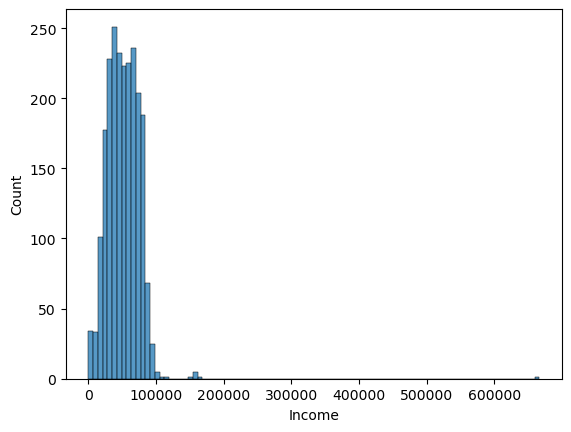

In [9]:
# Basic
sns.histplot(data=marketing_data, x="Income")

Phần lớn khách hàng trong chiến dịch marketing này có mức thu nhập dao động chủ yếu trong khoảng từ $30,000$ đến $80,000$ (đây là nơi các cột nhô cao nhất, đạt đỉnh ở mức gần 250 khách hàng cho một khoảng thu nhập). Đây chính là nhóm khách hàng mục tiêu số một mà các chiến dịch quảng cáo cần nhắm vào.

<Axes: xlabel='Income', ylabel='Count'>

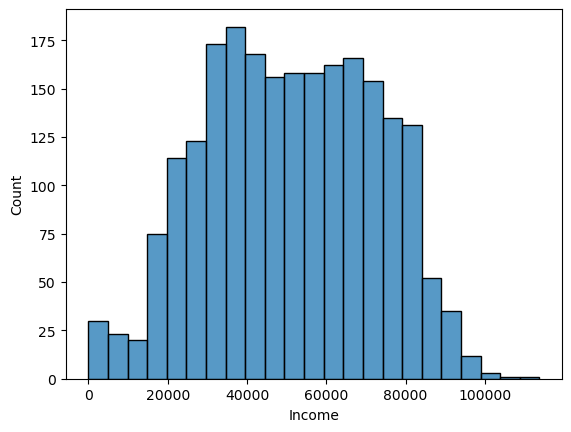

In [10]:
# Xử lý Outliers và vẽ lại biểu đồ
marketing_data_clean = marketing_data[marketing_data['Income'] < 150000]
import seaborn as sns
sns.histplot(data=marketing_data_clean, x="Income")

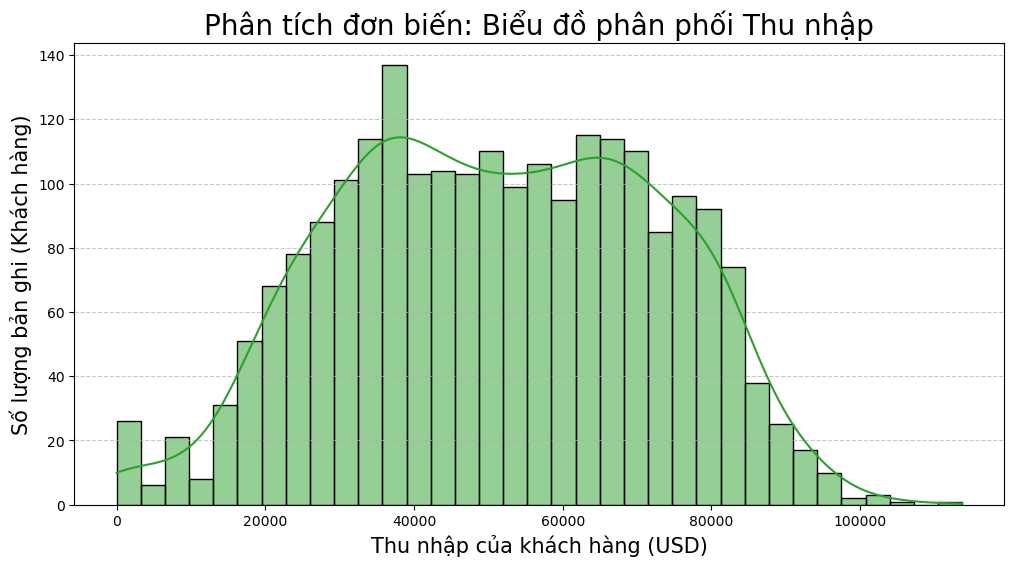

In [11]:
# Advanced
# Tăng kích thước khung tranh (Chiều ngang 12, Chiều cao 6)
plt.figure(figsize=(12, 6)) 

# Vẽ biểu đồ Histogram nâng cao
ax = sns.histplot(
    data=marketing_data_clean,x="Income",bins=35,kde=True,color="#2ca02c") 
ax.set_xlabel('Thu nhập của khách hàng (USD)', fontsize=15) 
ax.set_ylabel('Số lượng bản ghi (Khách hàng)', fontsize=15)
ax.set_title('Phân tích đơn biến: Biểu đồ phân phối Thu nhập', fontsize=20)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

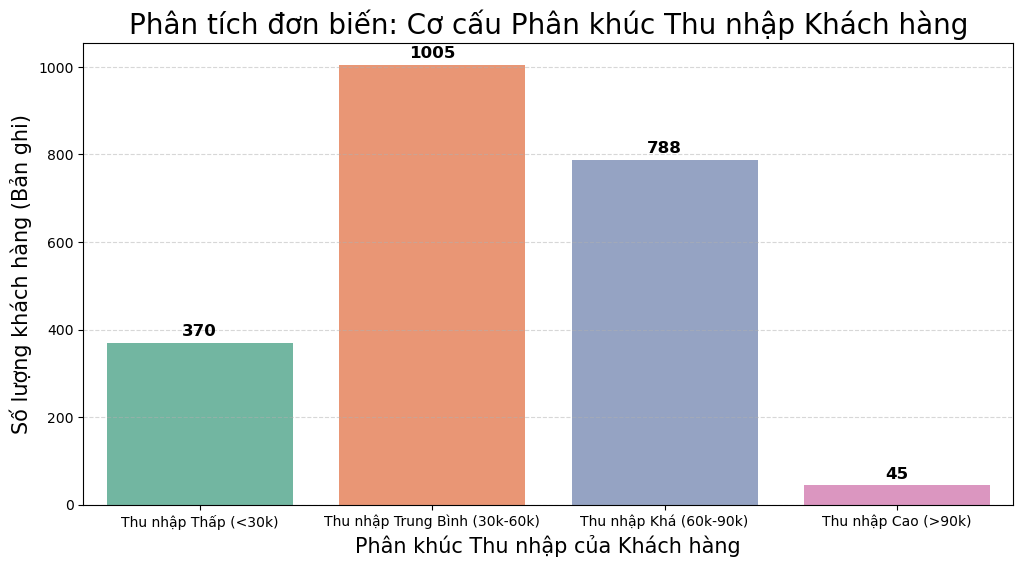

In [16]:
# Phân tích đơn biến bằng bar chart
# Chia nhóm phân khúc tiền lương thành 4 khoảng: 0-30k (Thấp), 30k-60k (Trung bình), 60k-90k (Khá), 90k+ (Cao)
marketing_data_clean = marketing_data[marketing_data['Income'] < 150000].copy()
bins = [0, 30000, 60000, 90000, 150000]
labels = ['Thu nhập Thấp (<30k)', 'Thu nhập Trung Bình (30k-60k)', 'Thu nhập Khá (60k-90k)', 'Thu nhập Cao (>90k)']

marketing_data_clean['Income_Group'] = pd.cut(marketing_data_clean['Income'], bins=bins, labels=labels)
# Vẽ biểu đồ:
plt.figure(figsize=(12, 6)) 
ax = sns.countplot(
    data=marketing_data_clean, 
    x='Income_Group', 
    palette='Set2',          
    hue='Income_Group',
    legend=False
)
# Cấu hình nhãn và tiêu đề
ax.set_xlabel('Phân khúc Thu nhập của Khách hàng', fontsize=15) 
ax.set_ylabel('Số lượng khách hàng (Bản ghi)', fontsize=15)
ax.set_title('Phân tích đơn biến: Cơ cấu Phân khúc Thu nhập Khách hàng', fontsize=20)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f'{int(p.get_height())}', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', 
            va='center', 
            xytext=(0, 8), 
            textcoords='offset points',
            fontsize=12,
            weight='bold'
        )
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

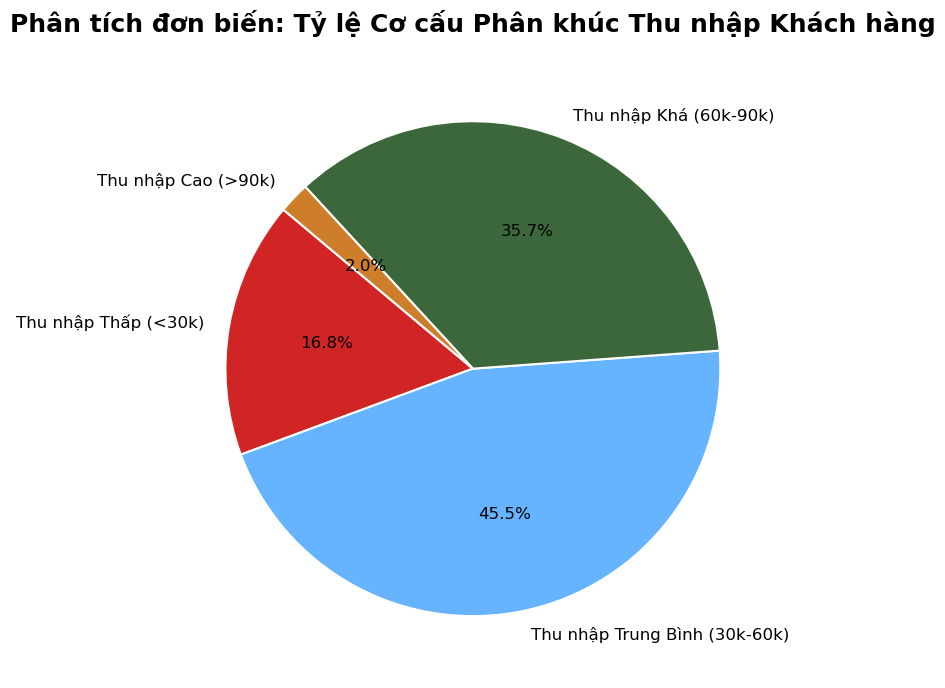

In [27]:
bins = [0, 30000, 60000, 90000, 150000]
labels = ['Thu nhập Thấp (<30k)', 'Thu nhập Trung Bình (30k-60k)', 'Thu nhập Khá (60k-90k)', 'Thu nhập Cao (>90k)']
marketing_data_clean['Income_Group'] = pd.cut(marketing_data_clean['Income'], bins=bins, labels=labels)
income_counts = marketing_data_clean['Income_Group'].value_counts()
income_counts = income_counts.reindex(labels)
plt.figure(figsize=(8, 8))
colors = ["#d12525", '#66b3ff', "#3b673b", "#ce7d2b"]

plt.pie(
    income_counts, 
    labels=income_counts.index,          
    autopct='%1.1f%%',                   
    startangle=140,                      
    colors=colors,                       
    textprops={'fontsize': 12},          
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5} 
)

plt.title('Phân tích đơn biến: Tỷ lệ Cơ cấu Phân khúc Thu nhập Khách hàng', fontsize=18, weight='bold', pad=20)
plt.tight_layout()
plt.show()

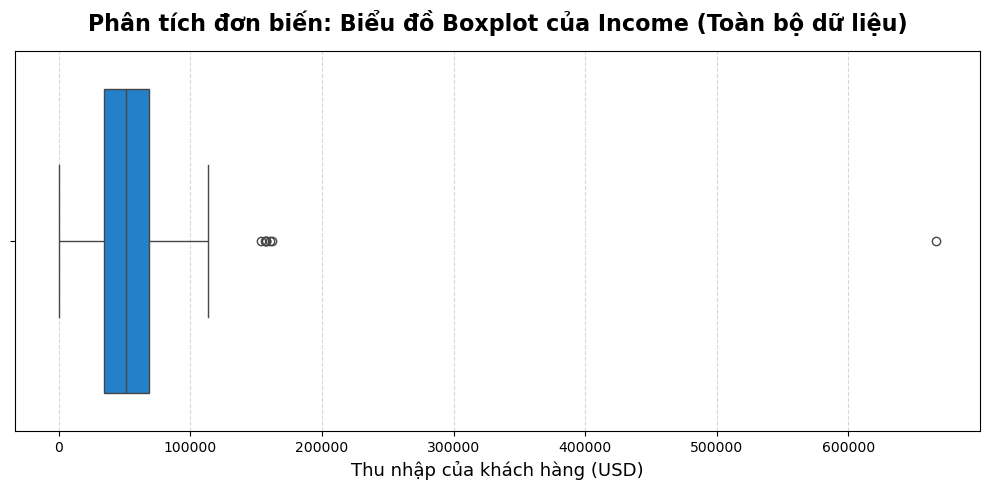

In [ ]:
# Phân tích đơn biến bằng Boxplot (Bao gồm giá trị ngoại lai)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Vẽ boxplot nằm ngang (orient='h') cho biến Income ban đầu
sns.boxplot(data=marketing_data, x='Income', color='#0984e3')

# Cấu hình nhãn và tiêu đề
plt.xlabel('Thu nhập của khách hàng (USD)', fontsize=13)
plt.title('Phân tích đơn biến: Biểu đồ Boxplot của Income (Toàn bộ dữ liệu)', fontsize=16, weight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

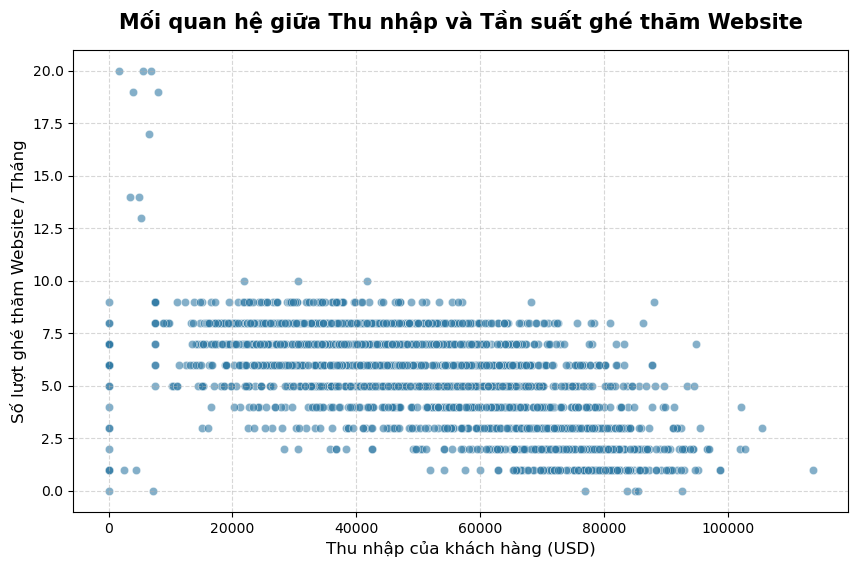

In [31]:
# %%
# Phân tích đa biến: Scatter plot giữa Thu nhập và Số lượt ghé thăm Website
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=marketing_data_clean, 
    x='Income', 
    y='NumWebVisitsMonth', 
    alpha=0.6, 
    color="#327ba5"
)

plt.xlabel('Thu nhập của khách hàng (USD)', fontsize=12)
plt.ylabel('Số lượt ghé thăm Website / Tháng', fontsize=12)
plt.title('Mối quan hệ giữa Thu nhập và Tần suất ghé thăm Website', fontsize=15, weight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [33]:
income_web_crosstab = pd.crosstab(
    index=marketing_data_clean['Income_Group'], 
    columns=marketing_data_clean['NumWebVisitsMonth']
)
print("Bảng chéo tần suất giữa Nhóm thu nhập và Số lượt ghé thăm Web:")
print(income_web_crosstab)

Bảng chéo tần suất giữa Nhóm thu nhập và Số lượt ghé thăm Web:
NumWebVisitsMonth              0    1    2    3    4    5    6    7    8   9   \
Income_Group                                                                    
Thu nhập Thấp (<30k)            1    2    1    7   13   35   66   93  106  36   
Thu nhập Trung Bình (30k-60k)   0    4   21   53   94  152  181  249  205  44   
Thu nhập Khá (60k-90k)          4  125  163  136  108   90   87   44   29   2   
Thu nhập Cao (>90k)             1   16   16    7    2    2    0    1    0   0   

NumWebVisitsMonth              10  13  14  17  19  20  
Income_Group                                           
Thu nhập Thấp (<30k)            1   1   2   1   2   3  
Thu nhập Trung Bình (30k-60k)   2   0   0   0   0   0  
Thu nhập Khá (60k-90k)          0   0   0   0   0   0  
Thu nhập Cao (>90k)             0   0   0   0   0   0  


In [35]:
# Sử dụng pivot_table và thêm observed=False để tắt cảnh báo FutureWarning
web_visits_pivot = pd.pivot_table(
    marketing_data_clean, 
    values='NumWebVisitsMonth', 
    index='Income_Group', 
    aggfunc='mean',
    observed=False
)

print("Số lượt ghé thăm Website trung bình theo từng phân khúc thu nhập:")
print(web_visits_pivot)

Số lượt ghé thăm Website trung bình theo từng phân khúc thu nhập:
                               NumWebVisitsMonth
Income_Group                                    
Thu nhập Thấp (<30k)                    7.127027
Thu nhập Trung Bình (30k-60k)           6.195025
Thu nhập Khá (60k-90k)                  3.579949
Thu nhập Cao (>90k)                     2.088889


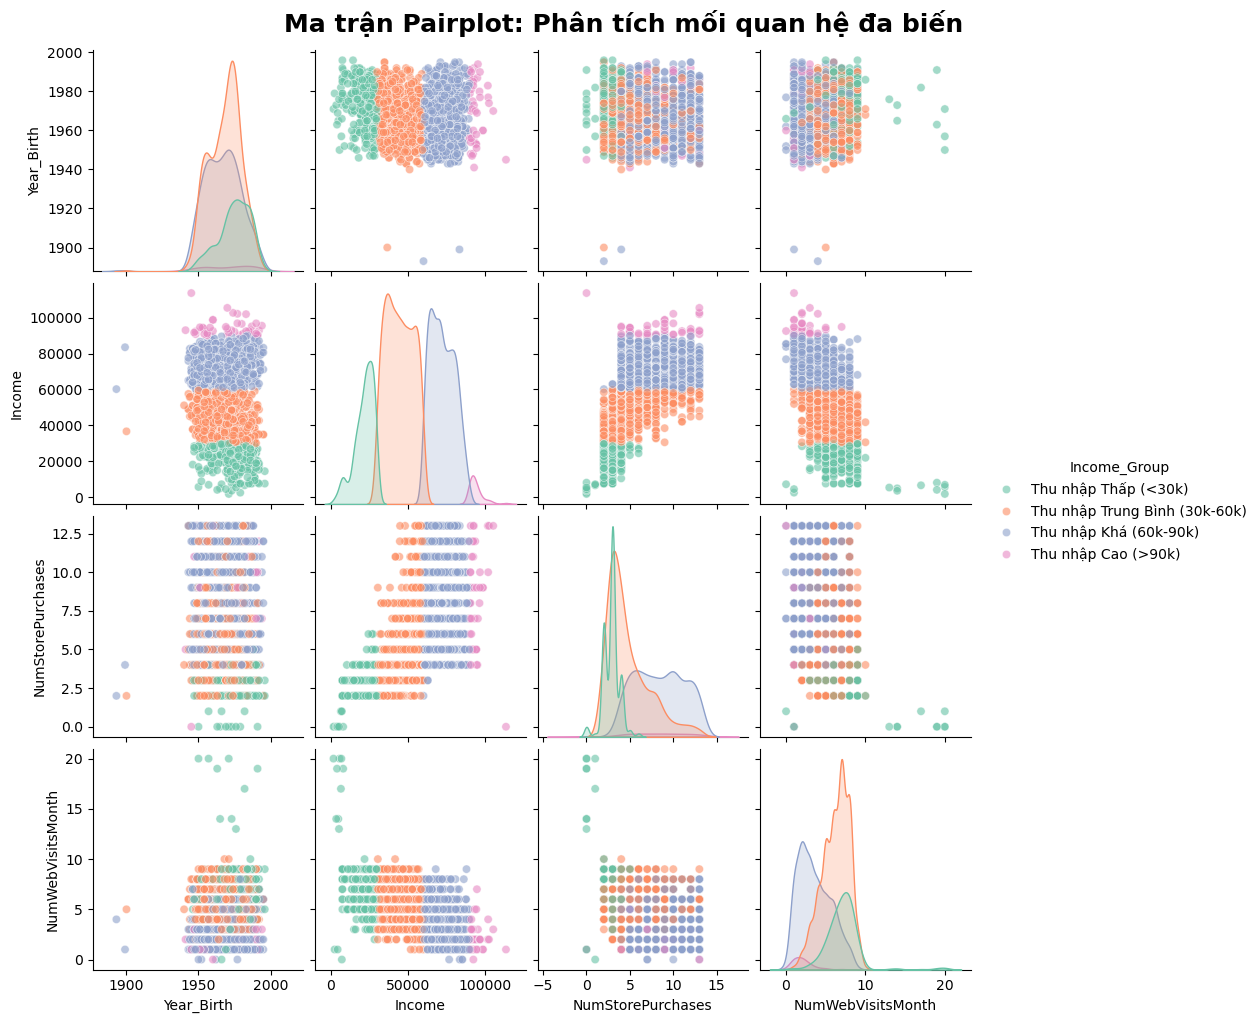

In [36]:
# Phân tích đa biến toàn diện bằng Pairplot cho các biến cốt lõi
import seaborn as sns
import matplotlib.pyplot as plt

# Bước 1: Chọn lọc các biến định lượng quan trọng để phân tích tương quan
cac_biens_so = ['Year_Birth', 'Income', 'NumStorePurchases', 'NumWebVisitsMonth']

# Bước 2: Vẽ pairplot nâng cao
# Thêm hue='Income_Group' để tô màu các chấm theo phân khúc thu nhập, giúp phát hiện xu hướng rõ ràng hơn!
g = sns.pairplot(
    data=marketing_data_clean, 
    vars=cac_biens_so, 
    hue='Income_Group', 
    palette='Set2',
    diag_kind='kde', # Vẽ đường cong mật độ ở đường chéo chính thay vì histogram
    plot_kws={'alpha': 0.6} # Làm mờ các chấm scatter để dễ nhìn các vùng chồng lấp
)

# Thêm tiêu đề tổng thể cho toàn bộ ma trận biểu đồ
g.fig.suptitle('Ma trận Pairplot: Phân tích mối quan hệ đa biến', fontsize=18, weight='bold', y=1.02)

plt.show()